<a href="https://colab.research.google.com/github/Farheen-18/AIProject/blob/main/AIproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving tweets.csv to tweets (2).csv
Dataset shape: (11370, 2)

Class distribution:
target
0    9256
1    2114
Name: count, dtype: int64

Class distribution (%):
target
0    81.407212
1    18.592788
Name: proportion, dtype: float64

Train shape: (9091, 5000)
Test shape : (2273, 5000)

--- Logistic Regression Config ---
  Regularization : l2
  C (strength)   : 1.0
  Solver         : liblinear
  Threshold      : 0.5

Logistic Regression
Accuracy            : 0.8649
Precision (class 0) : 0.8665
Precision (class 1) : 0.8452
Recall (class 0)    : 0.9859
Recall (class 1)    : 0.3357
F1 Macro            : 0.7015
F1 Weighted         : 0.8402
ROC-AUC             : 0.8997
PR-AUC              : 0.7154

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.87      0.99      0.92      1850
    Disaster       0.85      0.34      0.48       423

    accuracy                           0.86      2273
   macro avg       0.86      0.66      0.70      2273
weigh

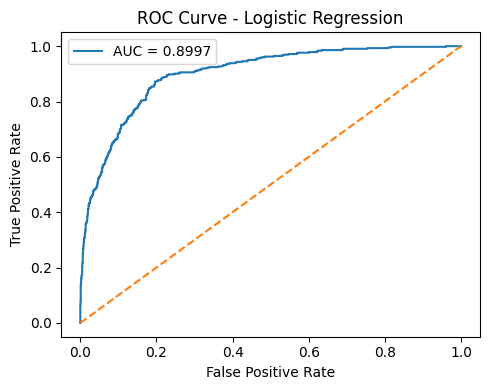

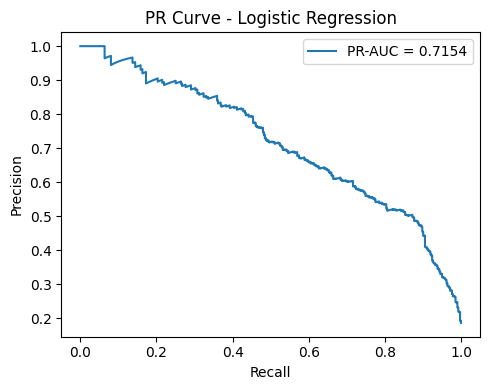


--- Random Forest Config ---
  N Estimators       : 100
  Max Depth          : 20
  Min Samples Split  : 5
  Min Samples Leaf   : 2

Random Forest
Accuracy            : 0.8289
Precision (class 0) : 0.8266
Precision (class 1) : 0.9722
Recall (class 0)    : 0.9995
Recall (class 1)    : 0.0827
F1 Macro            : 0.5287
F1 Weighted         : 0.7648
ROC-AUC             : 0.842
PR-AUC              : 0.6305

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.83      1.00      0.90      1850
    Disaster       0.97      0.08      0.15       423

    accuracy                           0.83      2273
   macro avg       0.90      0.54      0.53      2273
weighted avg       0.85      0.83      0.76      2273

Confusion Matrix:
[[1849    1]
 [ 388   35]]


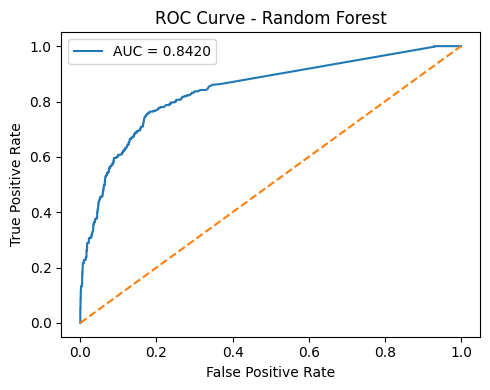

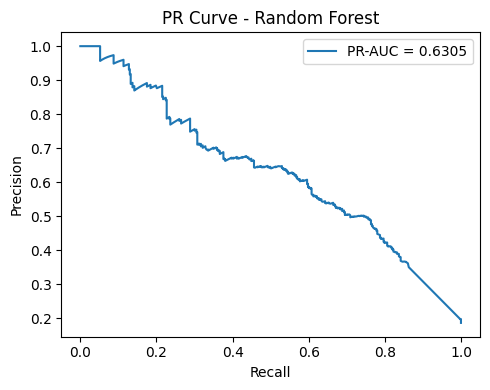


--- Neural Network Config ---
  Activation     : relu
  Learning Rate  : 0.001
  Optimizer      : adam
  Batch Size     : 64
  Epochs         : 20
  Dropout        : 0.3
  L2 Reg         : 0.0001
  Weight Init    : xavier
  Threshold      : 0.5

Training Neural Network...
  Epoch 5/20  Loss: 0.0907
  Epoch 10/20  Loss: 0.0200
  Epoch 15/20  Loss: 0.0185
  Epoch 20/20  Loss: 0.0142

Neural Network
Accuracy            : 0.8561
Precision (class 0) : 0.9163
Precision (class 1) : 0.6081
Recall (class 0)    : 0.9059
Recall (class 1)    : 0.6383
F1 Macro            : 0.767
F1 Weighted         : 0.8575
ROC-AUC             : 0.8633
PR-AUC              : 0.687

Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.92      0.91      0.91      1850
    Disaster       0.61      0.64      0.62       423

    accuracy                           0.86      2273
   macro avg       0.76      0.77      0.77      2273
weighted avg       0.86      0.86      0.86 

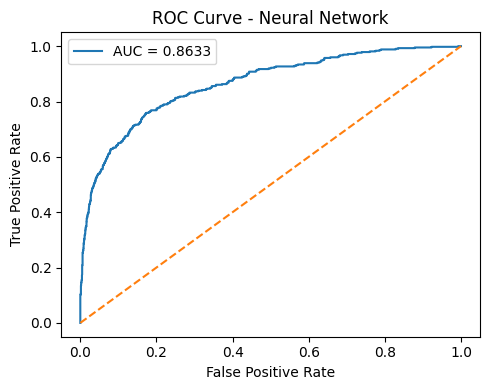

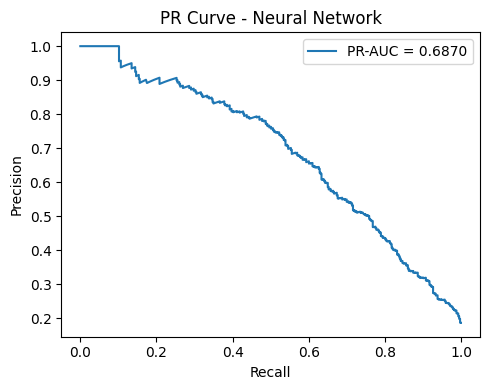


Part A completed successfully.


In [4]:
# ============================================================
# PART A: WITHOUT IMBALANCE HANDLING
# Models:
# 1. Logistic Regression
# 2. Random Forest
# 3. Neural Network
# ============================================================

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("tweets.csv")
df = df[["text", "target"]].dropna()

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["target"].value_counts())
print("\nClass distribution (%):")
print(df["target"].value_counts(normalize=True) * 100)

# ------------------------------------------------------------
# 2. Clean text
# ------------------------------------------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"@\w+", " ", text)             # remove mentions
    text = re.sub(r"#", " ", text)                # remove hashtag symbol
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # keep only letters
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

# ------------------------------------------------------------
# 3. Split data
# ------------------------------------------------------------
X = df["clean_text"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------
# 4. TF-IDF
# ------------------------------------------------------------
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 5. Evaluation function
# ------------------------------------------------------------
def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy            :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision (class 0) :", round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Precision (class 1) :", round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("Recall (class 0)    :", round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 4))
    print("Recall (class 1)    :", round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4))
    print("F1 Macro            :", round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4))
    print("F1 Weighted         :", round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4))
    print("ROC-AUC             :", round(roc_auc_score(y_true, y_prob), 4))

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    print("PR-AUC              :", round(pr_auc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["Not Disaster", "Disaster"],
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_prob):.4f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR Curve
    plt.figure(figsize=(5, 4))
    plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6. Logistic Regression
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
LR_PENALTY   = "l2"        # options: "l1" / "l2"
LR_C         = 1.0         # regularization strength (smaller = stronger)
LR_SOLVER    = "liblinear" # options: "liblinear" / "lbfgs" / "saga"
LR_THRESHOLD = 0.5         # decision threshold
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

print("\n--- Logistic Regression Config ---")
print(f"  Regularization : {LR_PENALTY}")
print(f"  C (strength)   : {LR_C}")
print(f"  Solver         : {LR_SOLVER}")
print(f"  Threshold      : {LR_THRESHOLD}")

lr_model = LogisticRegression(
    penalty=LR_PENALTY,
    C=LR_C,
    solver=LR_SOLVER,
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
lr_prob = lr_model.predict_proba(X_test)[:, 1]
evaluate_model("Logistic Regression", y_test, lr_prob, threshold=LR_THRESHOLD)

# ------------------------------------------------------------
# 7. Random Forest
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
RF_N_ESTIMATORS      = 100  # number of trees
RF_MAX_DEPTH         = 20   # max depth per tree (controls overfitting)
RF_MIN_SAMPLES_SPLIT = 5    # min samples required to split a node
RF_MIN_SAMPLES_LEAF  = 2    # min samples required at a leaf node
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

print("\n--- Random Forest Config ---")
print(f"  N Estimators       : {RF_N_ESTIMATORS}")
print(f"  Max Depth          : {RF_MAX_DEPTH}")
print(f"  Min Samples Split  : {RF_MIN_SAMPLES_SPLIT}")
print(f"  Min Samples Leaf   : {RF_MIN_SAMPLES_LEAF}")

rf_model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
evaluate_model("Random Forest", y_test, rf_prob, threshold=0.5)

# ------------------------------------------------------------
# 8. Neural Network (PyTorch)
# Fixed architecture: Input -> 64 -> 32 -> 16 -> Output
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# TUNABLE CONFIG
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ACTIVATION    = "relu"     # options: "relu" / "leakyrelu" / "tanh" / "elu"
LEARNING_RATE = 0.001
OPTIMIZER     = "adam"     # options: "adam" / "sgd" / "rmsprop"
BATCH_SIZE    = 64
EPOCHS        = 20
DROPOUT       = 0.3        # 0.0 means no dropout
L2_REG        = 1e-4       # weight decay (L2 regularization)
INIT          = "xavier"   # options: "xavier" / "he" / "uniform"
NN_THRESHOLD  = 0.5        # decision threshold
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

print("\n--- Neural Network Config ---")
print(f"  Activation     : {ACTIVATION}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Optimizer      : {OPTIMIZER}")
print(f"  Batch Size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Dropout        : {DROPOUT}")
print(f"  L2 Reg         : {L2_REG}")
print(f"  Weight Init    : {INIT}")
print(f"  Threshold      : {NN_THRESHOLD}")

class TextNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(TextNeuralNet, self).__init__()

        act_map = {
            "relu":      nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "tanh":      nn.Tanh(),
            "elu":       nn.ELU()
        }
        act = act_map.get(ACTIVATION, nn.ReLU())

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

        self.act     = act
        self.dropout = nn.Dropout(DROPOUT)

        # Weight initialization
        for fc in [self.fc1, self.fc2, self.fc3, self.fc4]:
            if INIT == "xavier":
                nn.init.xavier_uniform_(fc.weight)
            elif INIT == "he":
                if ACTIVATION in ["relu", "leakyrelu"]:
                    nn.init.kaiming_uniform_(fc.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(fc.weight)   # safer for tanh/elu
            elif INIT == "uniform":
                nn.init.uniform_(fc.weight, -0.1, 0.1)
            nn.init.zeros_(fc.bias)

    def forward(self, x):
        x = self.dropout(self.act(self.fc1(x)))
        x = self.dropout(self.act(self.fc2(x)))
        x = self.act(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x.squeeze(1)


# Prepare tensors
X_train_dense  = X_train.toarray().astype(np.float32)
X_test_dense   = X_test.toarray().astype(np.float32)
X_train_tensor = torch.tensor(X_train_dense)
y_train_tensor = torch.tensor(y_train.to_numpy().astype(np.float32))
X_test_tensor  = torch.tensor(X_test_dense)

# DataLoader
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Model, loss, optimizer
nn_model  = TextNeuralNet(input_dim=X_train_dense.shape[1])
criterion = nn.BCELoss()
opt_map   = {
    "adam":    torch.optim.Adam(nn_model.parameters(),    lr=LEARNING_RATE, weight_decay=L2_REG),
    "sgd":     torch.optim.SGD(nn_model.parameters(),     lr=LEARNING_RATE, weight_decay=L2_REG),
    "rmsprop": torch.optim.RMSprop(nn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_REG)
}
optimizer = opt_map.get(OPTIMIZER, torch.optim.Adam(nn_model.parameters(), lr=LEARNING_RATE))

# Training loop
print("\nTraining Neural Network...")
for epoch in range(EPOCHS):
    nn_model.train()
    total_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(nn_model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss/len(train_loader):.4f}")

# Inference
nn_model.eval()
with torch.no_grad():
    nn_prob = nn_model(X_test_tensor).cpu().numpy()

evaluate_model("Neural Network", y_test, nn_prob, threshold=NN_THRESHOLD)

print("\nPart A completed successfully.")